# Base Feature Engineering
**Goal:** Create raw market data.
**Key Operations:**
1.  **Data Preparation:** Load raw Parquet data, process splits, and interpolate missing values.
2.  **Indicators:** Calculate a wide array of technical indicators (SMA, EMA, ATR, BB, etc.).

In [1]:
# --- Base Feature Engineering ---
# Goal: Create raw market data.

# 1) WIPE & PURGE
%reset -f
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 2) IMPORTS
import os
import psutil
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

# Standardize display
pd.set_option('display.max_columns', None)

# 3) CUSTOM LIBRARIES
from libs import preps, plots, params, feats
importlib.reload(preps)
importlib.reload(plots)
importlib.reload(params)
importlib.reload(feats)

print(f"🚀 Memory Cleaned. Environment Ready for {params.ticker}")


🚀 Memory Cleaned. Environment Ready for AAPL


[process_splits] Loading original Parquet: dfs/AAPL_0_alpaca.parquet
Plotting original data...


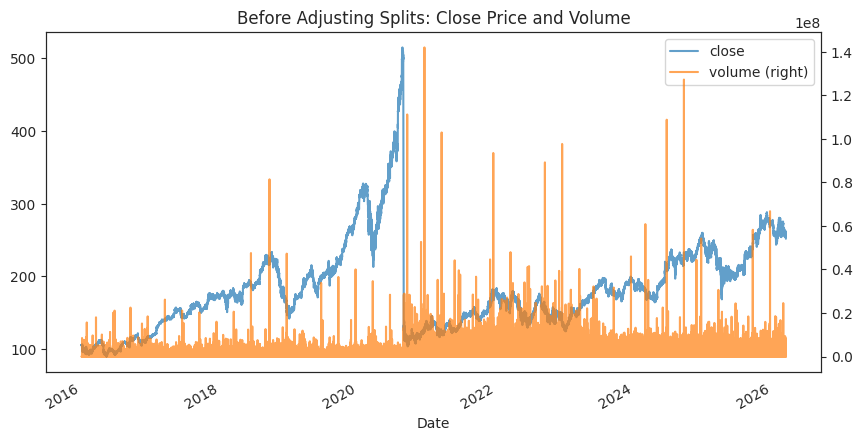

Executing [detect_and_adjust_splits]...
Detected forward split on 2020-08-31 08:00:00 with factor 4 (ratio: 0.2514)
Splits detected (1). Plotting adjusted data...


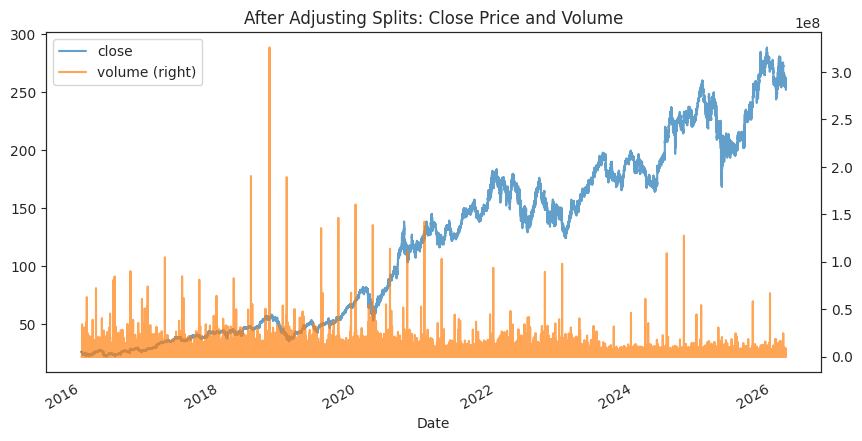

[executing prepare_interpolate_data]
Normalizing timezones...
Interpolating missing bars...
Filtering flat sessions...


Saving Parquet: 100%|██████████| 96/96 [00:01<00:00, 65.83it/s]


,open,high,low,close,volume,trade_count,vwap,ask,bid
2015-12-31 23:00:00,26.3575,26.3575,26.3575,26.3575,700.000000,1.0,105.430000,26.362775,26.352225
2015-12-31 23:01:00,26.3500,26.3500,26.3500,26.3500,2020.000000,5.0,105.400000,26.355275,26.344725
2015-12-31 23:02:00,26.3500,26.3500,26.3500,26.3500,1593.333333,4.0,105.400000,26.355275,26.344725
2015-12-31 23:03:00,26.3500,26.3500,26.3500,26.3500,1166.666667,3.0,105.400000,26.355275,26.344725
2015-12-31 23:04:00,26.3500,26.3500,26.3500,26.3500,740.000000,2.0,105.400000,26.355275,26.344725
...,...,...,...,...,...,...,...,...,...
2026-03-13 15:41:00,252.1700,252.1800,252.0400,252.1000,54024.000000,1008.0,252.132389,252.150400,252.049600
2026-03-13 15:42:00,252.0850,252.1800,252.0402,252.1000,89398.000000,1339.0,252.109872,252.150400,252.049600
2026-03-13 15:43:00,252.1000,252.1000,251.8900,251.9301,99873.000000,2114.0,251.998252,251.980500,251.879700
2026-03-13 15:44:00,251.9150,251.9300,251.6598,251.7199,79542.000000,2049.0,251.769574,251.770200,251.669600


In [2]:
print(f"[process_splits] Loading original Parquet: {params.alpaca_parquet}")

# 1. Load from Parquet (Much faster than CSV)
df_input = pd.read_parquet(params.alpaca_parquet)

# 1. Cleaning and preparing base data 
df = preps.process_splits(df=df_input, ticker=params.ticker)
df = preps.prepare_interpolate_data(df=df)

# 2. Index Cleanup: Ensure 1-minute frequency and naive UTC
df.index = pd.to_datetime(df.index).floor('min').tz_localize(None)

# Save cleaned base data
params.to_parquet_with_progress(df, params.base_parquet)

df

In [ ]:
# --- TECHNICAL INDICATORS ---
# Calculate a wide array of SMA, EMA, RSI, MACD, etc.
df_inds_unsc = feats.standard_indicators(
    df,
    sma=[5, 9, 21, 50, 100],
    ema=[5, 9, 13, 21, 50],
    atr=[7, 14, 21, 28],
    bb={20: [2.0, 3.0], 50: [2.0]},
    rsi=[7, 14, 21, 28],
    roc=[5, 10, 21],
    vol_spike=[7, 14, 28],
    obv_roll=[7, 21],
    ret_std=[21, 63],
    macd=[
        {"fast": 6, "slow": 13, "signal": 5},
        {"fast": 12, "slow": 26, "signal": 9},
    ],
    stoch=[
        {"k": 14, "d": 3, "smooth": 3},
        {"k": 9, "d": 3, "smooth": 3},
    ],
    cci=[14, 20],
    mfi=[14, 20],
    cmf=[14, 20],
    donch=[20, 55],
    roll_vwap=[20, 50],
    linreg_slope=[20, 50],
    kc=[
        {"ema_window": 20, "atr_window": 20, "atr_mult": 1.5},
        {"ema_window": 20, "atr_window": 20, "atr_mult": 2.0},
    ],
    psar={"step": 0.02, "max_step": 0.2},
)

# Save unscaled indicators 
params.to_parquet_with_progress(df_inds_unsc, params.indunsc_parquet)

df_inds_unsc

Indicators:   0%|          | 0/20 [00:00<?, ?it/s]